In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time
import math

import torch
import cupy as cp

BLOCK_SIZE = 16

In [20]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
!nvidia-smi

True
Thu Mar 26 12:39:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             29W /   70W |     429MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [21]:
# Load data
data = np.loadtxt('MLoGPU_data3_train.csv', delimiter=',')
X = data[:, :-1]
y = data[:, -1]

X_cp = cp.array(X, dtype=cp.float32)
y_cp = cp.array(y, dtype=cp.int32)

# Take all classes
classes = cp.unique(y_cp)
classes = classes.astype(int).tolist()

In [22]:
# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X_cp, y_cp, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3000, 7) (1000, 7) (3000,) (1000,)


In [23]:
# Data normalization
mean_train = X_train.mean()
std_train = X_train.std()

X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

In [24]:
# No train needed for kNN

In [25]:
compute_distances = cp.RawKernel(r""" extern "C"
    __global__ void compute_distances(
        const float* X_train, const float* X_test, const float* y_train,
        float* distances, float* labels,
        int n_train, int n_test, int features
    ) {
        int train_idx = blockIdx.x * blockDim.x + threadIdx.x;
        int test_idx  = blockIdx.y * blockDim.y + threadIdx.y;

        if (train_idx >= n_train || test_idx >= n_test)
            return;

        float dist = 0.;

        for(int i = 0; i < features; i++) {{
            float diff = X_train[train_idx * features + i] - X_test[test_idx * features + i];
            dist += diff * diff;
        }}

        distances[test_idx * n_train + train_idx] = dist;
        labels[test_idx * n_train + train_idx] = y_train[train_idx];

    }
    """, name="compute_distances")

In [26]:
n_train = X_train_norm.shape[0]
n_test = X_test_norm.shape[0]
features = X_train_norm.shape[1]

distances = cp.zeros((n_test, n_train))
labels = cp.zeros((n_test, n_train))

In [27]:
numThreadsPerBlock = 32
numBlocksx = math.ceil(distances.shape[1]/numThreadsPerBlock)
numBlocksy = math.ceil(distances.shape[0]/numThreadsPerBlock)

In [28]:
grid_x = (n_train + BLOCK_SIZE - 1) // BLOCK_SIZE
grid_y = (n_test  + BLOCK_SIZE - 1) // BLOCK_SIZE


cp.cuda.Stream.null.synchronize()
start_time = time.time()

compute_distances(
    (grid_x, grid_y),
    (BLOCK_SIZE, BLOCK_SIZE),
    (X_train, X_test, y_train,
     distances, labels,
     n_train, n_test, features)
)

# Merge distances + labels
dists = cp.stack((distances, labels), axis=2)  # shape (n_test, n_train, 2)

# Sort by distance only
sorted_idx = cp.argsort(dists[:, :, 0], axis=1)
sorted_dists = cp.take_along_axis(dists, sorted_idx[:, :, None], axis=1)

# Extract correctly sorted labels
sorted_labels = sorted_dists[:, :, 1].astype(cp.int32)

cp.cuda.Stream.null.synchronize()
dists_time = time.time() - start_time
print(f'Execution time forcalculationg distances: {dists_time:.4f}s')

Execution time forcalculationg distances: 0.0182s


In [ ]:
knn_predict = cp.RawKernel(
f'''#define NUM_CLASSES {len(classes)}\n'''
+ r''' extern "C" __global__ void knn_predict(
    const int* sorted_labels, int* predictions,
    int n_test, int k
){
    int test_idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (test_idx >= n_test)
        return;

    // Local counter array – stack allocated
    int counts[NUM_CLASSES];
    for (int i = 0; i < NUM_CLASSES; i++)
        counts[i] = 0;

    const int* labels = sorted_labels + test_idx * k;

    // Count occurrences
    for (int i = 0; i < k; i++) {
        int lbl = labels[i];
        if (lbl >= 0 && lbl < NUM_CLASSES)
            counts[lbl]++;
    }

    // Find mode
    int max_count = -1;
    int max_label = 0;
    for (int cls = 0; cls < NUM_CLASSES; cls++) {
        if (counts[cls] > max_count) {
            max_count = counts[cls];
            max_label = cls;
        }
    }

    predictions[test_idx] = max_label;
}
''', name="knn_predict")

In [ ]:
preds_all_k = []
accuracies = []
exec_times = []

k_values = range(1, 10)

block = 256
n_test = sorted_labels.shape[0]

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]
    grid = (n_test + block - 1) // block

    cp.cuda.Stream.null.synchronize()
    start = time.time()

    sorted_labels_k = sorted_labels[:, :K_VALUE].astype(cp.int32)
    predictions = cp.zeros(n_test, dtype=cp.int32)

    knn_predict((grid,), (block,),
                (sorted_labels_k, predictions, n_test, K_VALUE))

    cp.cuda.Stream.null.synchronize()
    exec_times.append(time.time() - start)

    # Confusion matrix
    preds_cpu = cp.asnumpy(predictions)
    y_test_cpu = cp.asnumpy(y_test)

    cm = confusion_matrix(y_test_cpu, preds_cpu, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    acc = np.trace(cm) / len(preds_cpu) * 100

    accuracies.append(acc)
    preds_all_k.append(preds_cpu)

(0.0, 100.0)

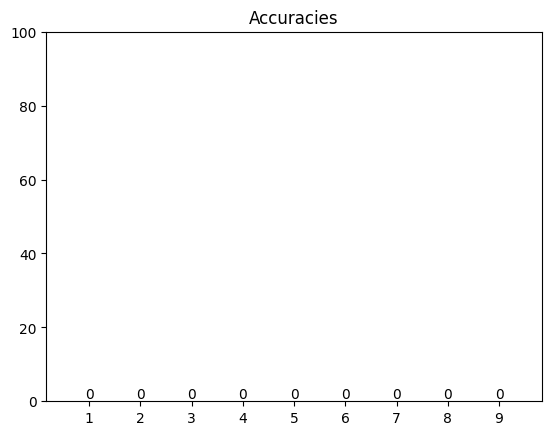

In [39]:
# Accuracies
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars)
plt.title('Accuracies')
plt.xticks(k_values)
plt.ylim((0,100))